In [15]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("/BankChurners.csv")
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [8]:
df.isnull().sum()

,0
CLIENTNUM,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0
Months_on_book,0


In [9]:
total_customers = df.shape[0]

churned_customers = df[df['Attrition_Flag'] == 'Attrited Customer'].shape[0]

existing_customers = df[df['Attrition_Flag'] == 'Existing Customer'].shape[0]

churn_rate = (churned_customers / total_customers) * 100

avg_credit_limit = df['Credit_Limit'].mean()
avg_transaction_amt = df['Total_Trans_Amt'].mean()
avg_utilization = df['Avg_Utilization_Ratio'].mean()

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Existing Customers:", existing_customers)
print("Churn Rate:", round(churn_rate, 2), "%")
print("Average Credit Limit:", round(avg_credit_limit, 2))
print("Average Transaction Amount:", round(avg_transaction_amt, 2))
print("Average Utilization Ratio:", round(avg_utilization, 2))

Total Customers: 10127
Churned Customers: 1627
Existing Customers: 8500
Churn Rate: 16.07 %
Average Credit Limit: 8631.95
Average Transaction Amount: 4404.09
Average Utilization Ratio: 0.27


In [10]:
gender_churn = pd.crosstab(df['Gender'], df['Attrition_Flag'])

gender_churn['Churn_Rate_%'] = (
    gender_churn['Attrited Customer'] /
    (gender_churn['Attrited Customer'] + gender_churn['Existing Customer'])
) * 100

gender_churn

Attrition_Flag,Attrited Customer,Existing Customer,Churn_Rate_%
Gender,,,
F,930,4428,17.357223
M,697,4072,14.615223


In [11]:
income_churn = pd.crosstab(df['Income_Category'], df['Attrition_Flag'])

income_churn['Churn_Rate_%'] = (
    income_churn['Attrited Customer'] /
    (income_churn['Attrited Customer'] + income_churn['Existing Customer'])
) * 100

income_churn.sort_values('Churn_Rate_%', ascending=False)

Attrition_Flag,Attrited Customer,Existing Customer,Churn_Rate_%
Income_Category,,,
$120K +,126,601,17.331499
Less than $40K,612,2949,17.186184
Unknown,187,925,16.816547
$80K - $120K,242,1293,15.765472
$40K - $60K,271,1519,15.139665
$60K - $80K,189,1213,13.480742


In [12]:
card_churn = pd.crosstab(df['Card_Category'], df['Attrition_Flag'])

card_churn['Churn_Rate_%'] = (
    card_churn['Attrited Customer'] /
    (card_churn['Attrited Customer'] + card_churn['Existing Customer'])
) * 100

card_churn.sort_values('Churn_Rate_%', ascending=False)

Attrition_Flag,Attrited Customer,Existing Customer,Churn_Rate_%
Card_Category,,,
Platinum,5,15,25.000000
Gold,21,95,18.103448
Blue,1519,7917,16.097923
Silver,82,473,14.774775


In [13]:
inactive_churn = df.groupby('Attrition_Flag')['Months_Inactive_12_mon'].mean()

inactive_churn

,Months_Inactive_12_mon
Attrition_Flag,
Attrited Customer,2.693301
Existing Customer,2.273765


In [14]:
transaction_churn = df.groupby('Attrition_Flag')['Total_Trans_Amt'].mean()

transaction_churn

,Total_Trans_Amt
Attrition_Flag,
Attrited Customer,3095.025814
Existing Customer,4654.655882


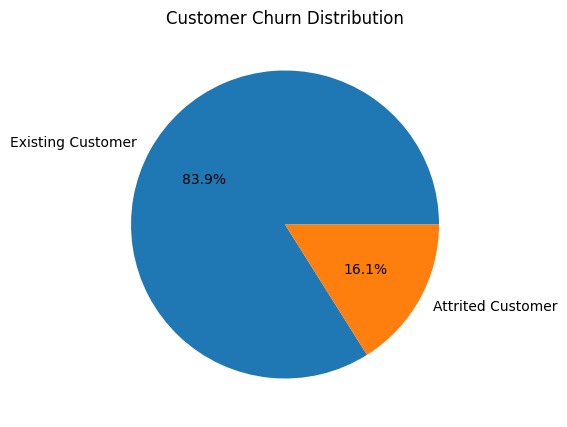

In [16]:
churn_counts = df['Attrition_Flag'].value_counts()

plt.figure(figsize=(6,5))
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%')
plt.title('Customer Churn Distribution')
plt.show()

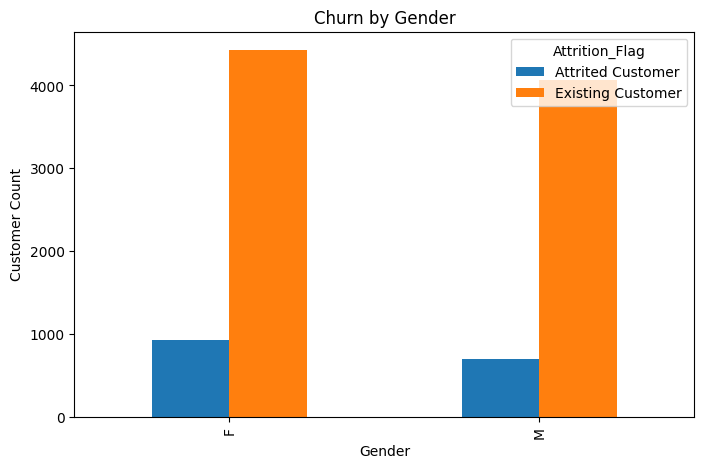

In [17]:
gender_churn = pd.crosstab(df['Gender'], df['Attrition_Flag'])

gender_churn.plot(kind='bar', figsize=(8,5))

plt.title('Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Customer Count')
plt.show()

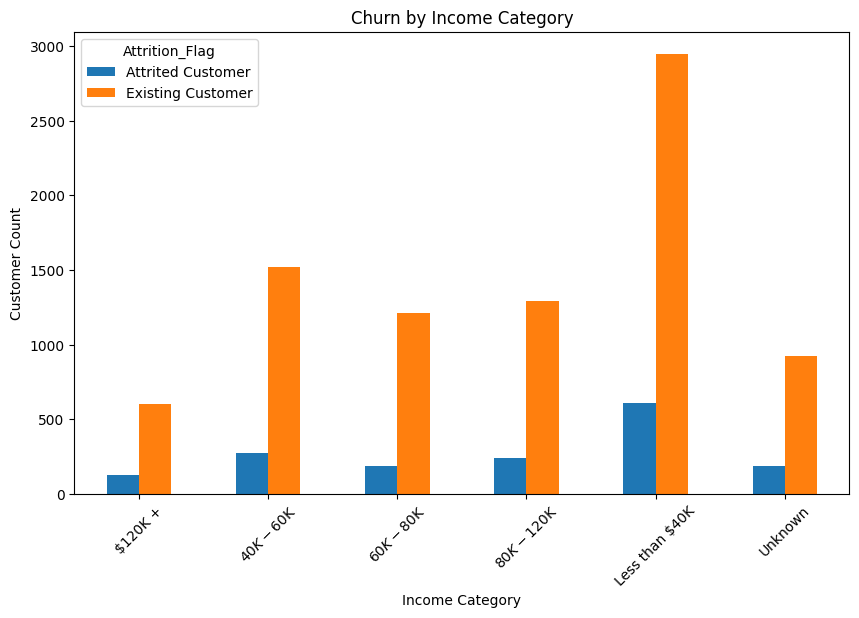

In [18]:
income_churn = pd.crosstab(df['Income_Category'], df['Attrition_Flag'])

income_churn.plot(kind='bar', figsize=(10,6))

plt.title('Churn by Income Category')
plt.xlabel('Income Category')
plt.ylabel('Customer Count')
plt.xticks(rotation=45)
plt.show()

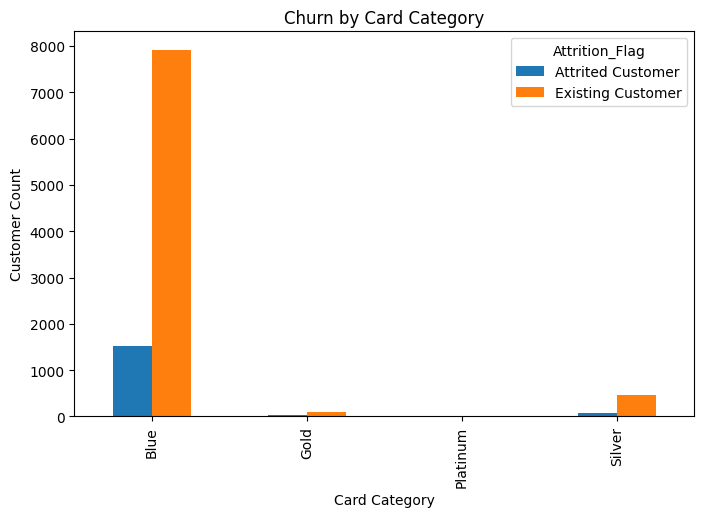

In [19]:
card_churn = pd.crosstab(df['Card_Category'], df['Attrition_Flag'])

card_churn.plot(kind='bar', figsize=(8,5))

plt.title('Churn by Card Category')
plt.xlabel('Card Category')
plt.ylabel('Customer Count')
plt.show()

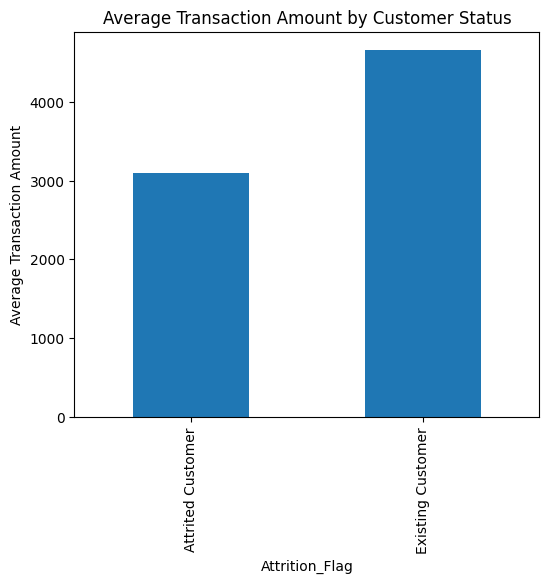

In [20]:
df.groupby('Attrition_Flag')['Total_Trans_Amt'].mean().plot(kind='bar', figsize=(6,5))

plt.title('Average Transaction Amount by Customer Status')
plt.ylabel('Average Transaction Amount')
plt.show()

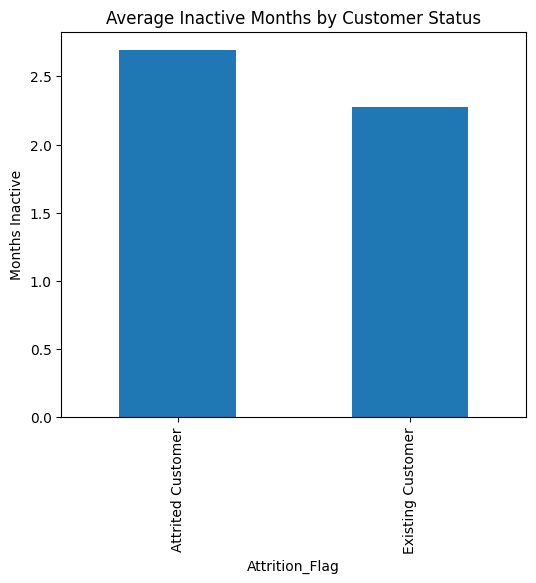

In [21]:
df.groupby('Attrition_Flag')['Months_Inactive_12_mon'].mean().plot(kind='bar', figsize=(6,5))

plt.title('Average Inactive Months by Customer Status')
plt.ylabel('Months Inactive')
plt.show()

In [22]:
df['Customer_Segment'] = pd.qcut(
    df['Credit_Limit'],
    q=4,
    labels=['Low Value', 'Mid Value', 'High Value', 'Premium']
)

df['Customer_Segment'].value_counts()

,count
Customer_Segment,
Low Value,2535
Premium,2532
Mid Value,2531
High Value,2529


In [23]:
segment_churn = pd.crosstab(df['Customer_Segment'], df['Attrition_Flag'])

segment_churn['Churn_Rate_%'] = (
    segment_churn['Attrited Customer'] /
    (segment_churn['Attrited Customer'] + segment_churn['Existing Customer'])
) * 100

segment_churn.sort_values('Churn_Rate_%', ascending=False)

Attrition_Flag,Attrited Customer,Existing Customer,Churn_Rate_%
Customer_Segment,,,
Low Value,517,2018,20.394477
High Value,387,2142,15.302491
Premium,369,2163,14.573460
Mid Value,354,2177,13.986567


In [24]:
df['Engagement_Risk'] = pd.cut(
    df['Months_Inactive_12_mon'],
    bins=[0, 2, 4, 6],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

pd.crosstab(df['Engagement_Risk'], df['Attrition_Flag'])

Attrition_Flag,Attrited Customer,Existing Customer
Engagement_Risk,,
Low Risk,605,4910
Medium Risk,956,3325
High Risk,51,251


In [25]:
churned = df[df['Attrition_Flag'] == 'Attrited Customer']

churned.describe(include='all')

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2,Customer_Segment,Engagement_Risk
count,1.627000e+03,1627,1627.000000,1627,1627.000000,1627,1627,1627,1627,1627.000000,...,1627.000000,1627.000000,1627.000000,1627.000000,1627.000000,1627.000000,1627.000000,1627.000000,1627,1612
unique,NaN,1,NaN,2,NaN,7,4,6,4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,3
top,NaN,Attrited Customer,NaN,F,NaN,Graduate,Married,Less than $40K,Blue,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low Value,Medium Risk
freq,NaN,1627,NaN,930,NaN,487,709,612,1519,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,517,956
mean,7.352614e+08,NaN,46.659496,NaN,2.402581,NaN,NaN,NaN,NaN,36.178242,...,7463.216472,0.694277,3095.025814,44.933620,0.554386,0.162475,0.994909,0.005091,NaN,NaN
std,3.557725e+07,NaN,7.665652,NaN,1.275010,NaN,NaN,NaN,NaN,7.796548,...,9109.208129,0.214924,2308.227629,14.568429,0.226854,0.264458,0.004303,0.004303,NaN,NaN
min,7.080833e+08,NaN,26.000000,NaN,0.000000,NaN,NaN,NaN,NaN,13.000000,...,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.945910,0.000420,NaN,NaN
25%,7.123713e+08,NaN,41.000000,NaN,2.000000,NaN,NaN,NaN,NaN,32.000000,...,1587.000000,0.544500,1903.500000,37.000000,0.400000,0.000000,0.994300,0.002825,NaN,NaN
50%,7.165644e+08,NaN,47.000000,NaN,2.000000,NaN,NaN,NaN,NaN,36.000000,...,3488.000000,0.701000,2329.000000,43.000000,0.531000,0.000000,0.996310,0.003688,NaN,NaN
75%,7.683737e+08,NaN,52.000000,NaN,3.000000,NaN,NaN,NaN,NaN,40.000000,...,9257.500000,0.856000,2772.000000,51.000000,0.692000,0.231000,0.997170,0.005700,NaN,NaN


In [26]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

numeric_df.corr()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
CLIENTNUM,1.000000,0.007613,0.006772,0.134588,0.006907,0.005729,0.005694,0.005708,0.000825,0.005633,0.017369,-0.019692,-0.002961,0.007696,0.000266,-0.046411,0.046410
Customer_Age,0.007613,1.000000,-0.122254,0.788912,-0.010931,0.054361,-0.018452,0.002476,0.014780,0.001151,-0.062042,-0.046446,-0.067097,-0.012143,0.007114,0.018189,-0.018189
Dependent_count,0.006772,-0.122254,1.000000,-0.103062,-0.039076,-0.010768,-0.040505,0.068065,-0.002688,0.068291,-0.035439,0.025046,0.049912,0.011087,-0.037135,0.019189,-0.019189
Months_on_book,0.134588,0.788912,-0.103062,1.000000,-0.009203,0.074164,-0.010774,0.007507,0.008623,0.006732,-0.048959,-0.038591,-0.049819,-0.014072,-0.007541,0.013693,-0.013694
Total_Relationship_Count,0.006907,-0.010931,-0.039076,-0.009203,1.000000,-0.003675,0.055203,-0.071386,0.013726,-0.072601,0.050119,-0.347229,-0.241891,0.040831,0.067663,-0.149981,0.149981
Months_Inactive_12_mon,0.005729,0.054361,-0.010768,0.074164,-0.003675,1.000000,0.029493,-0.020394,-0.042210,-0.016605,-0.032247,-0.036982,-0.042787,-0.038989,-0.007503,0.153452,-0.153452
Contacts_Count_12_mon,0.005694,-0.018452,-0.040505,-0.010774,0.055203,0.029493,1.000000,0.020817,-0.053913,0.025646,-0.024445,-0.112774,-0.152213,-0.094997,-0.055471,0.205772,-0.205772
Credit_Limit,0.005708,0.002476,0.068065,0.007507,-0.071386,-0.020394,0.020817,1.000000,0.042493,0.995981,0.012813,0.171730,0.075927,-0.002020,-0.482965,-0.023853,0.023853
Total_Revolving_Bal,0.000825,0.014780,-0.002688,0.008623,0.013726,-0.042210,-0.053913,0.042493,1.000000,-0.047167,0.058174,0.064370,0.056060,0.089861,0.624022,-0.263033,0.263032
Avg_Open_To_Buy,0.005633,0.001151,0.068291,0.006732,-0.072601,-0.016605,0.025646,0.995981,-0.047167,1.000000,0.007595,0.165923,0.070885,-0.010076,-0.538808,-0.000267,0.000267


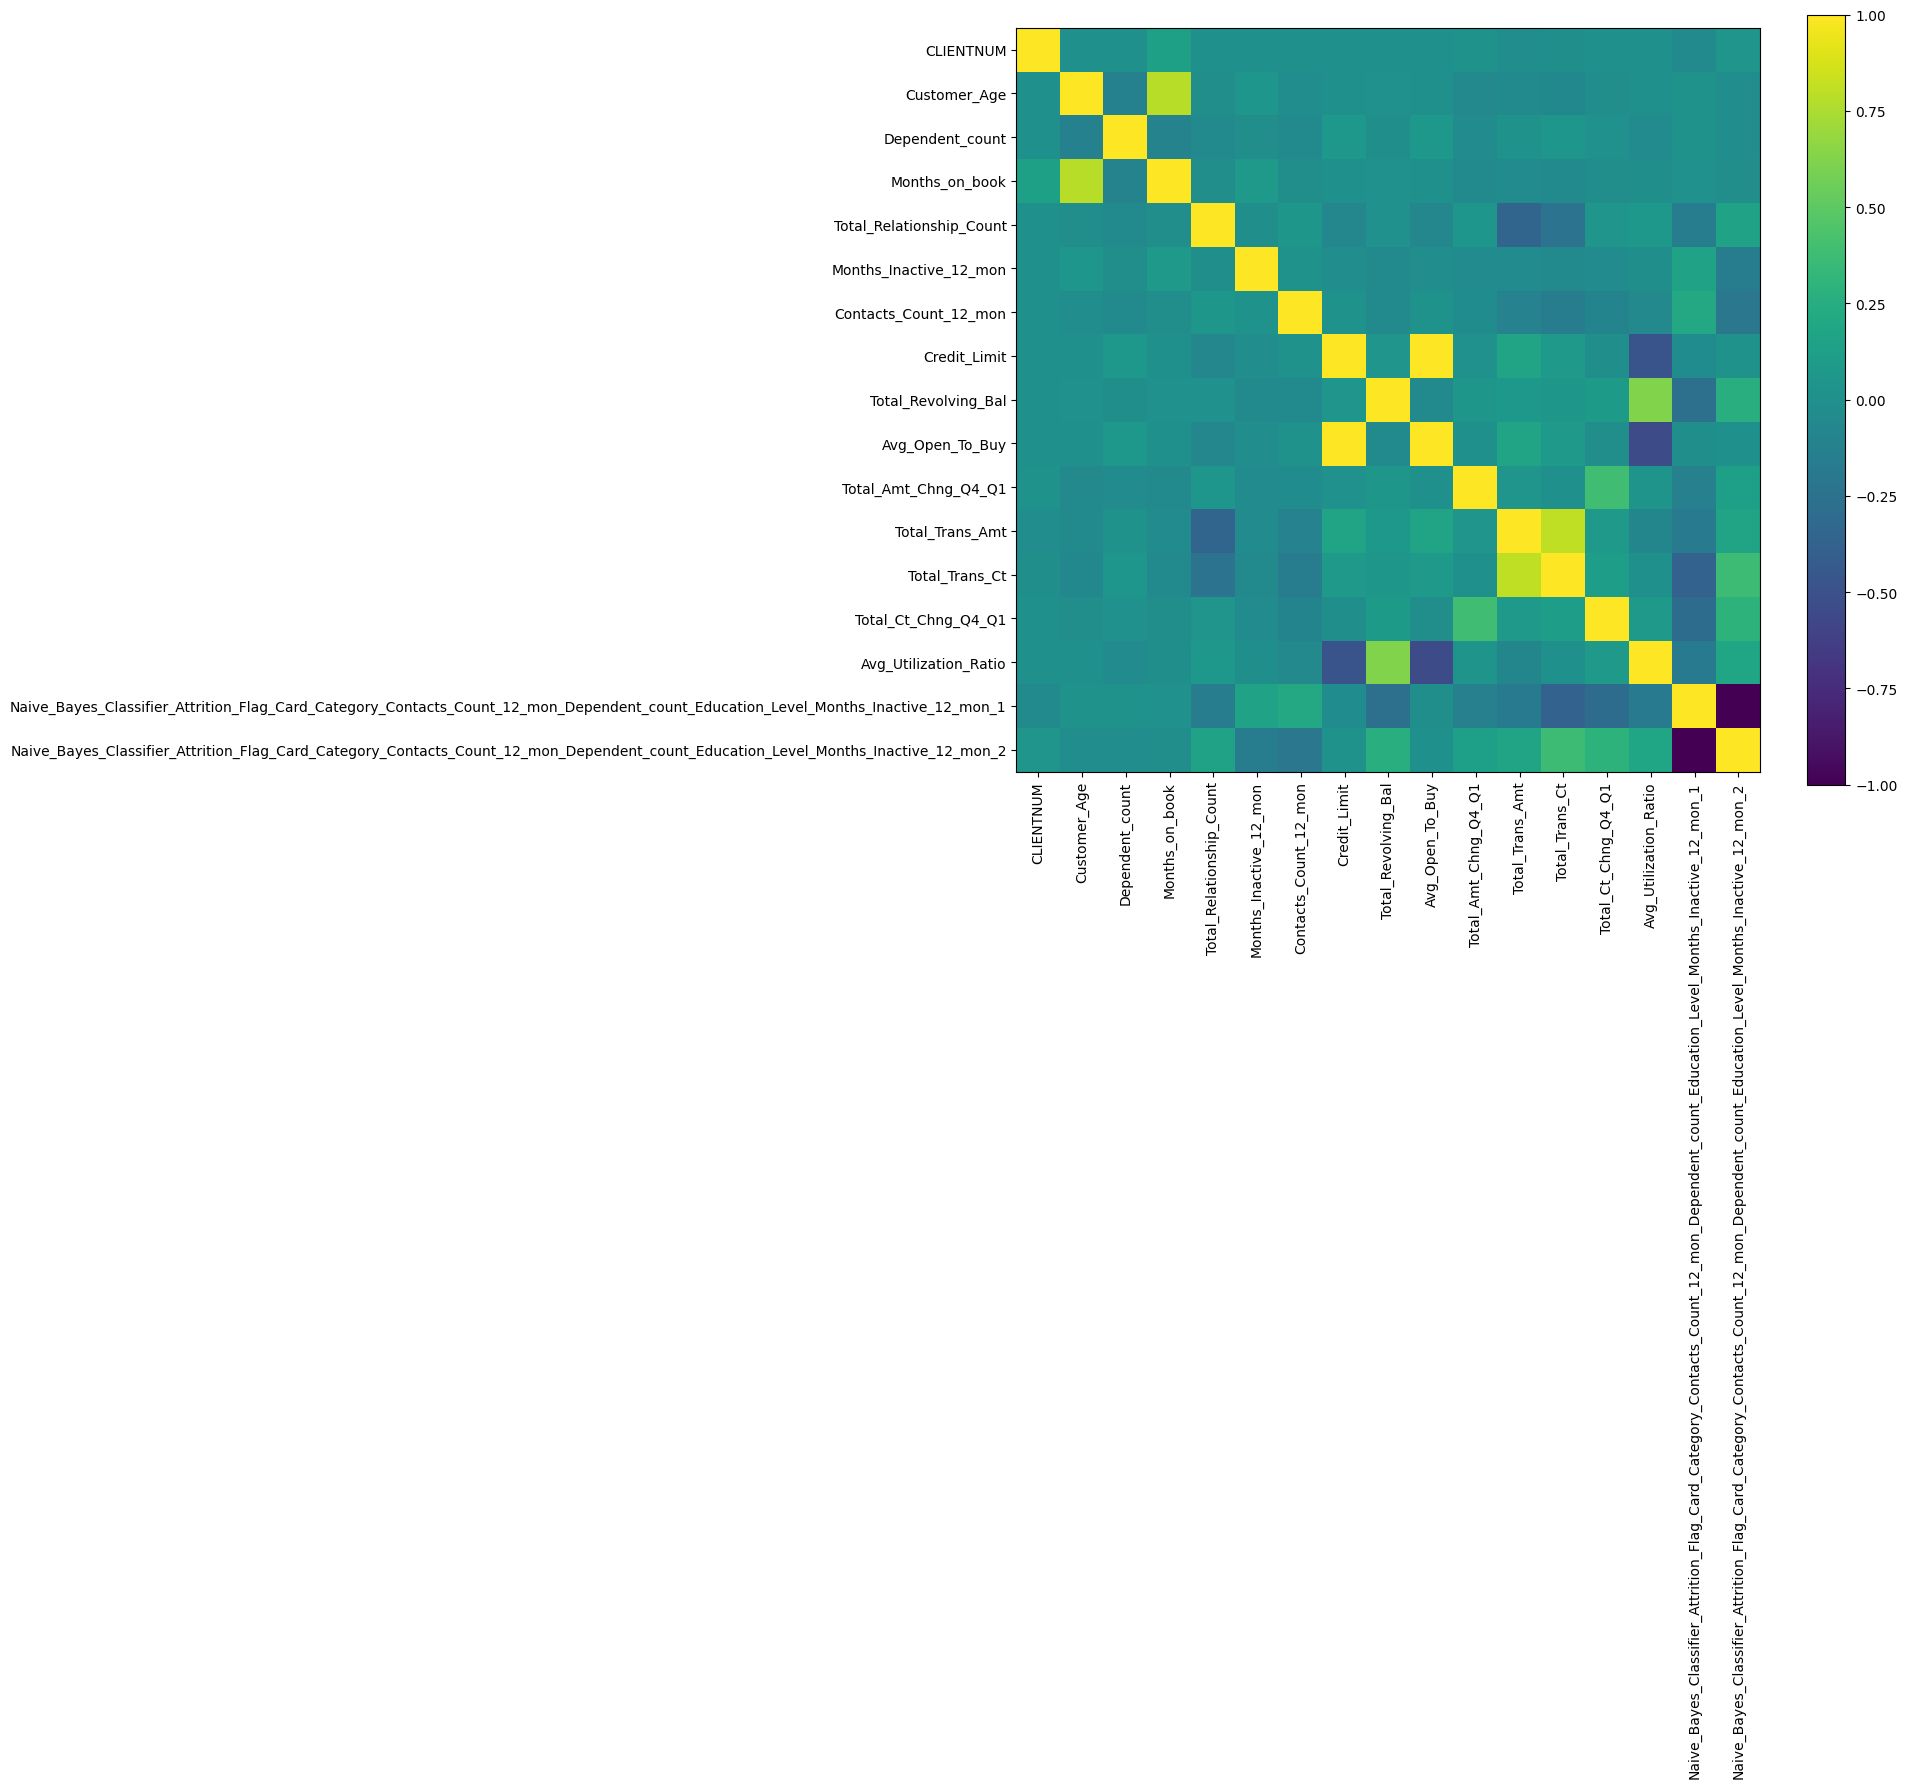

In [27]:
import matplotlib.pyplot as plt

corr = numeric_df.corr()

plt.figure(figsize=(12,10))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()